In [79]:
# Regression Using Sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Fixed line below:
plt.rcParams['figure.figsize'] = [10, 5]

import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)


In [80]:
full_data = pd.read_csv('/content/Nepali Housing Price Dataset.csv')

In [81]:
print('train data:', full_data.shape)

train data: (2211, 18)


In [82]:
full_data.head(5)

,Title,Address,City,Price,Bedroom,Bathroom,Floors,Parking,Face,Year,Views,Area,Road,Road Width,Road Type,Build Area,Posted,Amenities
0,Flat System House On Sale At Budhanikantha : H...,"Budhanikantha, Budhanilkantha, Kathmandu",Kathmandu,90000000,6,3,2.0,10,West,2073.0,17,1-0-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,18-0-0-0 Aana,11 hours ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
1,21 Aana Beautiful House : House For Sale In Bu...,"Pasikot, Budhanilkantha, Kathmandu",Kathmandu,80000000,5,3,2.0,9,East,2073.0,26,0-21-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-14-0-0 Aana,12 hours ago,"['Parking', 'Garage', 'Fencing', 'Frontyard', ..."
2,Beautiful To Floor House : House For Sale In D...,"Dhapasi, Dhapasi, Kathmandu",Kathmandu,70000000,5,3,2.0,12,East,2071.0,154,1-1-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,10-1-0-0 Aana,2 days ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
3,Modern Architecture Bungalow House : House For...,"baluwatar, Baluwatar, Kathmandu",Kathmandu,130000000,6,4,3.0,9,West,2017.0,17,0-10-1-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-7-1-0 Aana,1 day ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
4,Modern Bungalow House : House For Sale In Golf...,"Golfutar, Golfutar, Kathmandu",Kathmandu,100000000,6,3,2.0,10,East,2070.0,59,0-19-2-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-14-2-0 Aana,2 days ago,"['Parking', 'Lawn', 'Garage', 'Balcony', 'Back..."


In [83]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2211 entries, 0 to 2210
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       2211 non-null   object 
 1   Address     2211 non-null   object 
 2   City        2211 non-null   object 
 3   Price       2211 non-null   int64  
 4   Bedroom     2211 non-null   int64  
 5   Bathroom    2211 non-null   int64  
 6   Floors      1039 non-null   float64
 7   Parking     2211 non-null   int64  
 8   Face        2211 non-null   object 
 9   Year        582 non-null    float64
 10  Views       2211 non-null   object 
 11  Area        2211 non-null   object 
 12  Road        2211 non-null   object 
 13  Road Width  2211 non-null   object 
 14  Road Type   1426 non-null   object 
 15  Build Area  2211 non-null   object 
 16  Posted      2211 non-null   object 
 17  Amenities   2211 non-null   object 
dtypes: float64(2), int64(4), object(12)
memory usage: 311.1+ KB


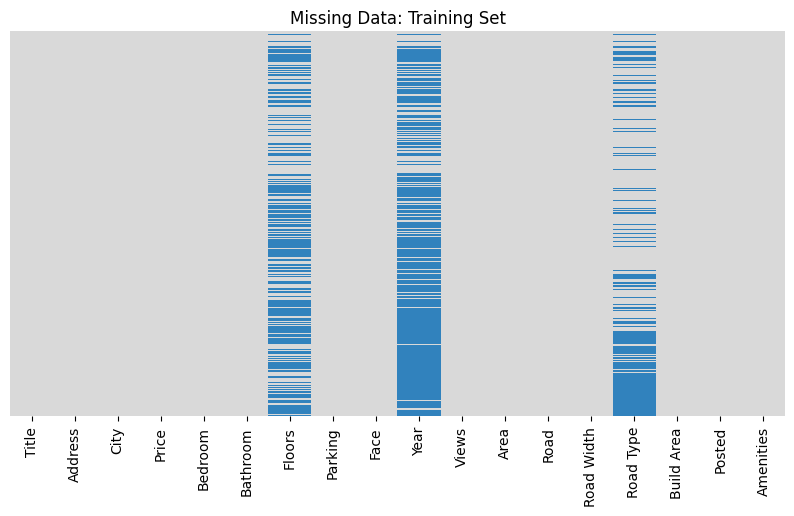

In [84]:

sns.heatmap(full_data.isnull(), yticklabels=False, cbar=False, cmap='tab20c_r')
plt.title('Missing Data: Training Set')
plt.show()


In [85]:
full_data.drop('Address', axis=1, inplace = True)

In [86]:
full_data.dropna(inplace=True)

In [88]:
full_data

,Title,City,Price,Bedroom,Bathroom,Floors,Parking,Face,Year,Views,Area,Road,Road Width,Road Type,Build Area,Posted,Amenities
0,Flat System House On Sale At Budhanikantha : H...,Kathmandu,90000000,6,3,2.0,10,West,2073.0,17,1-0-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,18-0-0-0 Aana,11 hours ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
1,21 Aana Beautiful House : House For Sale In Bu...,Kathmandu,80000000,5,3,2.0,9,East,2073.0,26,0-21-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-14-0-0 Aana,12 hours ago,"['Parking', 'Garage', 'Fencing', 'Frontyard', ..."
2,Beautiful To Floor House : House For Sale In D...,Kathmandu,70000000,5,3,2.0,12,East,2071.0,154,1-1-0-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,10-1-0-0 Aana,2 days ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
3,Modern Architecture Bungalow House : House For...,Kathmandu,130000000,6,4,3.0,9,West,2017.0,17,0-10-1-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-7-1-0 Aana,1 day ago,"['Parking', 'Lawn', 'Garage', 'Frontyard', 'Fe..."
4,Modern Bungalow House : House For Sale In Golf...,Kathmandu,100000000,6,3,2.0,10,East,2070.0,59,0-19-2-0 Aana,20 Feet / Blacktopped,20 Feet,Blacktopped,0-14-2-0 Aana,2 days ago,"['Parking', 'Lawn', 'Garage', 'Balcony', 'Back..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1697,"DeepLila Sadan : House For Sale In Dhapakhel, ...",Lalitpur,42000000,6,5,4.0,5,South West,2068.0,303,11 Aana,0 Feet / Blacktopped,0 Feet,Blacktopped,N/A Aana,11 months ago,"['Garage', 'Balcony', 'Garden', 'Water Supply'..."
1698,"Office Space For Rent In Kupondole, Lalitpur",Lalitpur,50000,3,2,2.0,4,East,2015.0,644,4.5 Aana,25 Feet / Blacktopped,25 Feet,Blacktopped,650 Sq. Feet,11 months ago,"['Drainage', 'Water Supply']"
1798,"BRIHAT HOUSING : House For Sale In Bhaisepati,...",Lalitpur,39077000,4,4,3.0,1,South,2076.0,5K,0-8-2-0 Aana,16 Feet / Concrete,16 Feet,Concrete,2300 Sq. Feet,1 year ago,"['Balcony', 'Fencing', 'Garden', 'TV Cable', '..."
1894,House For Sale Inside Ringroad : House For Sal...,Kathmandu,19500000,3,3,3.0,1,South East,2075.0,1.6K,0-2-3-0 Aana,12 Feet / Paved,12 Feet,Paved,N/A Sq. Feet,1 year ago,"['Garage', 'Balcony', 'Deck', 'Frontyard', 'Mo..."


In [89]:
full_data.describe()

,Price,Bedroom,Bathroom,Floors,Parking,Year
count,4.890000e+02,489.000000,489.000000,489.000000,489.000000,489.000000
mean,2.665958e+11,4.944785,3.989775,2.869836,2.194274,2059.402863
std,5.878780e+12,4.957919,2.754634,0.993769,2.781873,25.375364
min,5.000000e+01,0.000000,0.000000,0.000000,0.000000,1994.000000
25%,1.700000e+07,4.000000,3.000000,2.500000,1.000000,2050.000000
50%,2.550000e+07,5.000000,4.000000,3.000000,1.000000,2074.000000
75%,3.990000e+07,6.000000,5.000000,3.000000,3.000000,2076.000000
max,1.300000e+14,95.000000,40.000000,13.000000,31.000000,2077.000000


In [90]:
# shape of train data
full_data.shape

(489, 17)

In [91]:
full_data.columns = full_data.columns.str.strip()

x = full_data.drop('Price', axis=1)
y = full_data['Price']





In [92]:

print(full_data.columns.tolist())


['Title', 'City', 'Price', 'Bedroom', 'Bathroom', 'Floors', 'Parking', 'Face', 'Year', 'Views', 'Area', 'Road', 'Road Width', 'Road Type', 'Build Area', 'Posted', 'Amenities']


In [93]:
import pandas as pd
from sklearn import preprocessing

x_numerical = x.select_dtypes(include=['number'])


pre_process = preprocessing.StandardScaler()


x_transform = pre_process.fit_transform(x_numerical)


In [94]:
x_transform.shape
x_transform

array([[ 0.21305215, -0.35968065, -0.8761866 ,  2.80879768,  0.53638882],
       [ 0.01114808, -0.35968065, -0.8761866 ,  2.44895957,  0.53638882],
       [ 0.01114808, -0.35968065, -0.8761866 ,  3.5284739 ,  0.4574915 ],
       ...,
       [-0.190756  ,  0.00371571,  0.13111385, -0.42974531,  0.65473479],
       [-0.39266007, -0.35968065,  0.13111385, -0.42974531,  0.61528613],
       [-0.190756  ,  0.73050843, -0.37253637,  1.00960713,  0.57583748]])

In [95]:
y.shape

(489,)

In [96]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x_transform, y, test_size = .10, random_state = 101)

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [98]:
# predict
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(x_train, y_train)

y_pred = lm.predict(x_test)

print("Shape:", y_pred.shape)
print("Predictions:", y_pred)



Shape: (49,)
Predictions: [ 7.37285246e+10  7.46108913e+11 -8.71093602e+11  3.50185980e+10
  1.49895476e+11  2.98207233e+10  5.15990804e+10 -2.38071236e+10
 -2.37866429e+10 -7.02912661e+12  6.03762374e+11  9.00041230e+11
  1.37317265e+11  1.81718496e+11 -1.54277626e+11  1.81082724e+11
  1.50729218e+12  6.75314667e+11  1.23957246e+10  6.58876526e+11
 -8.89160843e+10  4.44005304e+11  9.05218624e+11  1.86280599e+11
  8.07299371e+11  4.77391513e+10  1.69842459e+11  8.76006932e+11
  3.27319400e+11  5.98855173e+11  1.59507123e+11  1.80589295e+11
  4.17571734e+10  1.80028543e+12  4.56279408e+11  6.74464753e+11
  1.80589295e+11  5.52393342e+11  1.36330407e+11  1.97663207e+11
 -1.32127701e+11  4.40171874e+11 -7.10814248e+10 -3.15065012e+10
  9.05732534e+11  7.76106547e+11  9.14526755e+11  3.55120272e+10
  1.80589295e+11]


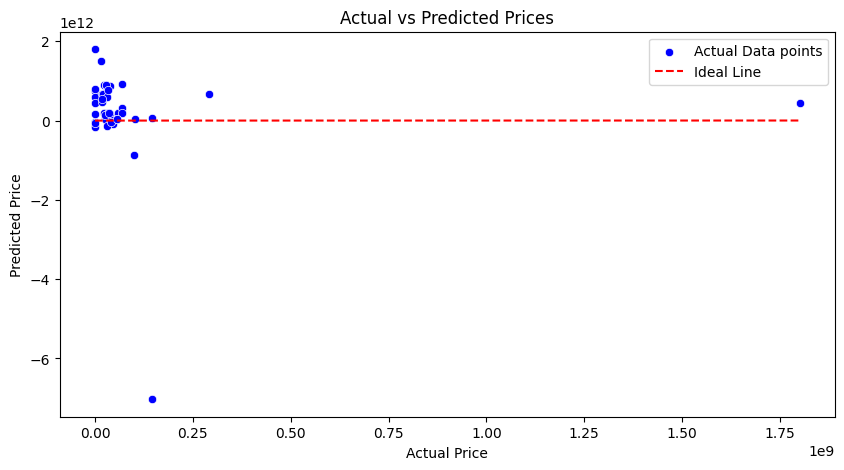

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Actual Data points')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Line')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()


In [100]:

residual = y_test - y_pred

print(residual)


527    -7.358352e+10
1698   -7.461089e+11
875     8.711936e+11
37     -3.499210e+10
591    -1.498605e+11
582    -2.977172e+10
315    -5.149658e+10
1054    2.380714e+10
1409    2.378677e+10
22      7.029272e+12
775    -6.037623e+11
634    -9.000172e+11
1247   -1.372803e+11
757    -1.816610e+11
309     1.542777e+11
732    -1.810472e+11
12     -1.507277e+12
715    -6.752977e+11
514    -1.236812e+10
690    -6.588570e+11
460     8.896108e+10
38     -4.440053e+11
1549   -9.051896e+11
661    -1.862471e+11
378    -8.072985e+11
23     -4.768415e+10
610    -1.698038e+11
632    -8.759684e+11
864    -3.272494e+11
46     -5.988247e+11
197    -1.595071e+11
326    -1.805668e+11
837    -4.171867e+10
721    -1.800285e+12
546    -4.562604e+11
729    -6.741748e+11
580    -1.805558e+11
1086   -5.523763e+11
914    -1.363049e+11
750    -1.975952e+11
229     1.321577e+11
1571   -4.383719e+11
329     7.108144e+10
419     3.154650e+10
642    -9.057045e+11
809    -7.760740e+11
2      -9.144568e+11
879    -3.545

<Axes: xlabel='Price', ylabel='Density'>

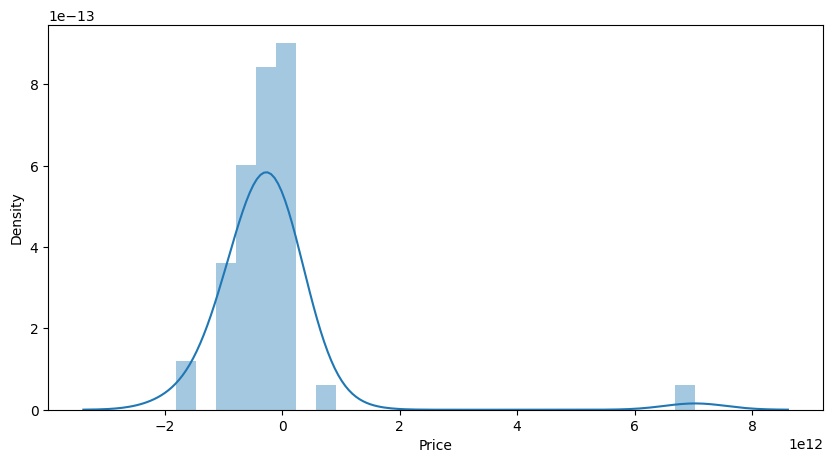

In [101]:
sns.distplot(residual, kde=True)

In [103]:
import numpy as np
from sklearn.metrics import mean_squared_error

print('Linear Regression Model')
print('_ _' * 30)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)


Linear Regression Model
_ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ _
Mean Squared Error: 1.3274976528617376e+24
Root Mean Squared Error: 1152170843608.5933


In [105]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


dt_model = DecisionTreeRegressor(random_state=101)
dt_model.fit(x_train, y_train)


dt_pred = dt_model.predict(x_test)


dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("--- Decision Tree Results ---")
print("RMSE:", round(dt_rmse, 2))
print("R2 Score:", round(dt_r2 * 100, 2), "%")


--- Decision Tree Results ---
RMSE: 261582400.07
R2 Score: -6.6 %


In [106]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=101)
gb_model.fit(x_train, y_train)

gb_pred = gb_model.predict(x_test)


gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("--- Gradient Boosting Results ---")
print("RMSE:", round(gb_rmse, 2))
print("R2 Score:", round(gb_r2 * 100, 2), "%")


--- Gradient Boosting Results ---
RMSE: 255435271.07
R2 Score: -1.65 %


In [107]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=101),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=101),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=101)
}

print(f"{'Model Name':<20} | {'RMSE':<15} | {'R2 Score (%)':<10}")
print("-" * 55)

for name, model in models.items():

    model.fit(x_train, y_train)


    predictions = model.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions) * 100

    print(f"{name:<20} | {rmse:<15.2f} | {r2:<10.2f}%")


Model Name           | RMSE            | R2 Score (%)
-------------------------------------------------------
Linear Regression    | 1152170843608.59 | -2068042739.01%
Decision Tree        | 261582400.07    | -6.60     %
Random Forest        | 2971430159732.12 | -13754880445.95%
Gradient Boosting    | 255435271.07    | -1.65     %
